<span style="font-size:20px;"><b>Actividad 3: Proyecto de ciencia de datos integrando Phyton y R</b></span>
<br>
<b>Fecha:</b> 22/06/2025
<br>
<b>Autor:</b> Lesly Alejandra Escobar Aguilar

<span style="font-size:25px;"><b> Elección del conjunto de datos y Limpieza y transformación de los datos</b></span>
<br>
<span style="font-size:15px;">Para este apartado estamos utilizando python para traer nuestro archivo excel Enchanced_pizza para poder realizar el respectivo analisis de datos. El dataset nos muestra el impacto de delivery para diferentes pizzerias, asi como el tiempo para la entrega, preferencia en el pago ya sea con tarjeta u otro medio, preferencia en el tamanio de la pizza, entre otros factores.</span>
<br>
<span style="font-size:15px;">Para la limpieza de datos empezamos por eliminar aquellos registros duplicados y los valores faltantes si un registro los tuviera, ademas se ha realizado el codigo necesario para que los campos necesarios tengan solamente dos decimales, tambien se ha hecho un cambbio en los campos de Order time, para que solo muestre la hora del pedido y en Delivery time para que solamente muestra la fecha en que se ha realizado el pedido.</span>
<br>
<span style="font-size:15px;">Tenemos un total de 1004 registros, al ser un dataset con una gran cantidad de columnas se han agregado estilos para poder mostrarlos de forma ordenada en una tabla</span>

In [2]:
# Librerías
import pandas as pd
from IPython.display import display, HTML

# Cargar el archivo Excel
df = pd.read_excel('Enhanced_pizza.xlsx')
df.columns = df.columns.str.strip()

#Descripcion 
df.info()
df.describe()
df.isnull().sum()

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar valores faltantes
df['Delivery Duration (min)'] = df['Delivery Duration (min)'].fillna(df['Delivery Duration (min)'].median())

# Corregir tipos de datos
df['Order Time'] = pd.to_datetime(df['Order Time'])
df['Delivery Time'] = pd.to_datetime(df['Delivery Time'])

# Nuevas columnas
df['Order_Date'] = df['Order Time'].dt.date

# Mostrar solo la hora en Order Time
df['Order Time'] = df['Order Time'].dt.strftime('%H:%M:%S')

# Mostrar solo la fecha en Delivery Time
df['Delivery Time'] = df['Delivery Time'].dt.strftime('%Y-%m-%d')

# Redondear columnas numéricas a 2 decimales
columnas_a_redondear = [
    'Delivery Duration (min)', 
    'Distance (km)', 
    'Delivery Efficiency (min/km)', 
    'Topping Density',
    'Estimated Duration (min)', 
    'Delay (min)', 
    'Restaurant Avg Time'
]

df[columnas_a_redondear] = df[columnas_a_redondear].round(2)

# Mostrar DataFrame con estilos
html_table = df.to_html(border=1, index=False)

# Estilo para que sea visible como tabla
styled_html = f"""
<div style="overflow-x:auto; max-height:500px;">
  {html_table}
</div>
"""

display(HTML(styled_html))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Order ID                      1004 non-null   object        
 1   Restaurant Name               1004 non-null   object        
 2   Location                      1004 non-null   object        
 3   Order Time                    1004 non-null   datetime64[ns]
 4   Delivery Time                 1004 non-null   datetime64[ns]
 5   Delivery Duration (min)       1004 non-null   int64         
 6   Pizza Size                    1004 non-null   object        
 7   Pizza Type                    1004 non-null   object        
 8   Toppings Count                1004 non-null   int64         
 9   Distance (km)                 1004 non-null   float64       
 10  Traffic Level                 1004 non-null   object        
 11  Payment Method                

Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Pizza Size,Pizza Type,Toppings Count,Distance (km),Traffic Level,Payment Method,Is Peak Hour,Is Weekend,Delivery Efficiency (min/km),Topping Density,Order Month,Payment Category,Estimated Duration (min),Delay (min),Is Delayed,Pizza Complexity,Traffic Impact,Order Hour,Restaurant Avg Time,Order_Date
ORD001,Domino's,"New York, NY",18:30:00,2024-01-05,15,Medium,Veg,3,2.5,Medium,Card,True,False,6.00,1.20,January,Online,6.00,9.00,False,6,2,18,30.26,2024-01-05
ORD002,Papa John's,"Los Angeles, CA",20:00:00,2024-02-14,25,Large,Non-Veg,4,5.0,High,Wallet,True,False,5.00,0.80,February,Online,12.00,13.00,False,12,3,20,28.19,2024-02-14
ORD003,Little Caesars,"Chicago, IL",12:15:00,2024-03-21,20,Small,Vegan,2,3.0,Low,UPI,False,False,6.67,0.67,March,Online,7.20,12.80,False,2,1,12,28.84,2024-03-21
ORD004,Pizza Hut,"Miami, FL",19:45:00,2024-04-10,25,XL,Cheese Burst,5,4.5,Medium,Cash,True,False,5.56,1.11,April,Offline,10.80,14.20,False,20,2,19,29.95,2024-04-10
ORD005,Marco's Pizza,"Dallas, TX",13:00:00,2024-05-05,20,Medium,Non-Veg,3,2.0,High,Card,False,True,10.00,1.50,May,Online,4.80,15.20,False,6,3,13,30.29,2024-05-05
ORD006,Domino's,"New York, NY",19:00:00,2024-01-06,20,Medium,Non-Veg,3,3.0,High,Card,True,True,6.67,1.00,January,Online,7.20,12.80,False,6,3,19,30.26,2024-01-06
ORD007,Papa John's,"Los Angeles, CA",20:15:00,2024-01-07,25,Large,Veg,4,4.5,Medium,UPI,True,True,5.56,0.89,January,Online,10.80,14.20,False,12,2,20,28.19,2024-01-07
ORD008,Little Caesars,"Chicago, IL",18:30:00,2024-01-08,20,Small,Vegan,2,2.0,Low,Cash,True,False,10.00,1.00,January,Offline,4.80,15.20,False,2,1,18,28.84,2024-01-08
ORD009,Pizza Hut,"Miami, FL",19:45:00,2024-01-09,25,XL,Cheese Burst,5,5.0,High,Wallet,True,False,5.00,1.00,January,Online,12.00,13.00,False,20,3,19,29.95,2024-01-09
ORD010,Marco's Pizza,"Dallas, TX",13:00:00,2024-01-10,20,Medium,Non-Veg,3,3.5,Medium,Card,False,False,5.71,0.86,January,Online,8.40,11.60,False,6,2,13,30.29,2024-01-10


<span style="font-size:25px;"><b>Implementacion de R</b></span>
<br>
<span style="font-size:15px;">Para este caso, para la configuracion de R, se ha tomado como base principalmente el codigo explicado en clase para la configuracion de RPy2. Este codigo nos funciona para poder implementar R en nuestro codigo python y asi obtener resultados de nuestro analisis a partir de ello.</span>

In [1]:
# Configuración de RPy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
# Importar paquetes R necesarios
print("\nImportando paquetes R...")
try:
    with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter) as cv:
        base = importr('base')
        stats = importr('stats')
        utils = importr('utils')
        
        r_packages = ['ggplot2', 'dplyr', 'lubridate', 'plotly']
        for pkg in r_packages:
            try:
                importr(pkg)
                print(f"  {pkg} cargado correctamente")
            except Exception as pkg_e:
                print(f"  Error al cargar {pkg}: {pkg_e}")
                print(f"  Intentando instalar {pkg}...")
                utils.install_packages(pkg)
                print(f"  {pkg} instalado y cargado")
                
        ggplot2 = importr('ggplot2')
        dplyr = importr('dplyr')
        lubridate = importr('lubridate')
        
except Exception as e:
    print(f"\n¡ERROR CRÍTICO! RPy2 o R no pudieron inicializarse correctamente: {e}")
    print("Por favor, revisa los pasos de instalación de R y RTools, y la configuración de PATH.")
    sys.exit(1) # Salir del script si hay un error fatal con R.

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
C:\Users\lesly\python_bootcamp\bootcamp03\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "PATH" redefined by R and overriding existing variable. Current: "C:\Users\lesly\python_bootcamp\bootcamp03\Scripts;C:\Program Files (x86)\Common Files\Oracle\Java\javapath;C:\windows\system32;C:\windows;C:\windows\System32\Wbem;C:\windows\System32\WindowsPowerShell\v1.0\;C:\windows\System32\OpenSSH\;C:\Program Files (x86)\Microsoft SQL Server\160\DTS\Binn\;C:\Program Files\Microsoft SQL Server\150\Tools\Binn\;C:\Program Files\Microsoft SQL Server\Client SDK\ODBC\170\Tools\Binn\;C:\Program Files\dotnet\;C:\Program Files (x86)\Windows Kits\10\Windows Performance Toolkit\;C:\Program Files\Git\cmd;C:\Users\lesly\AppData\Local\Programs\Python\Python313\Scripts\;C:\Users\lesly\AppData\Local\Programs\Python\Python313\;C:\Users\lesly\AppData\Local\Prog


Importando paquetes R...
  ggplot2 cargado correctamente
  dplyr cargado correctamente
  lubridate cargado correctamente


R callback write-console: Warning:  
R callback write-console:  package 'plotly' is in use and will not be installed
  


  Error al cargar plotly: list index out of range
  Intentando instalar plotly...
  plotly instalado y cargado


<span style="font-size:25px;"><b>Implementacion de R</b></span>
<br>
<span style="font-size:15px;">En este apartado lo que estamos intentando realizar es poder transferir nuestros resultados de python a lenguaje R para poder obtener calculos para nuestro analisis, entre ellos hemos realizado el calculo de Media, Mediana, Moda. Por medio de lenguaje R obtenemos nuestros calculos de columnas especificas del dataset para poder mostrarlos visualmente en nuestro notebook.</span>

In [21]:
# Transferir df de Python a R como un data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_df = ro.conversion.py2rpy(df)
# Resumen estadístico
ro.r('''
calculo <- function(df, columnas) {
  library(dplyr)

#Creación de DataFrame vacío para almacenar resultados
  resumen <- data.frame(
    Columna = character(),
    Media = numeric(),
    Mediana = numeric(),
    Moda = numeric(),
    Q1_25 = numeric(),
    Q2_50 = numeric(),
    Q3_75 = numeric(),
    Rango_min = numeric(),
    Rango_max = numeric(),
    IQR = numeric(),
    stringsAsFactors = FALSE
  )
  
  for (col in columnas) {
    x <- df[[col]]
    x <- x[!is.na(x)]
    media <- mean(x)
    mediana <- median(x)
    moda <- as.numeric(names(sort(table(x), decreasing=TRUE)[1]))
    cuartiles <- quantile(x, probs = c(0.25, 0.5, 0.75))
    rango <- range(x)
    iqr <- IQR(x)

#Calculo de estadisticas
    resumen <- rbind(resumen, data.frame(
      Columna = col,
      Media = round(media, 2),
      Mediana = round(mediana, 2),
      Moda = round(moda, 2),
      Cuartil1_25 = round(cuartiles[1], 2),
      Cuartil2_50 = round(cuartiles[2], 2),
      Cuartil3_75 = round(cuartiles[3], 2), 
      stringsAsFactors = FALSE
    ))
  }
  
  return(resumen)
}
''')

#Columnas a utilizar
columnas = [
    'Delivery Duration (min)', 
    'Distance (km)',
    'Delivery Efficiency (min/km)',
    'Topping Density',
    'Estimated Duration (min)',
    'Delay (min)',
    'Restaurant Avg Time'
]

# Analisis de columnas
resumen_df = ro.r['calculo'](r_df, columnas)

# Resultados de R a Python (visualizacion)
with localconverter(ro.default_converter + pandas2ri.converter):
    resumen_pd = ro.conversion.rpy2py(resumen_df)

print(resumen_pd)


                           Columna  Media  Mediana   Moda  Cuartil1_25  \
25%        Delivery Duration (min)  29.49    30.00  30.00        25.00   
25%1                 Distance (km)   4.95     4.50   4.00         3.50   
25%2  Delivery Efficiency (min/km)   6.40     6.00   5.00         5.00   
25%3               Topping Density   0.72     0.67   0.67         0.60   
25%4      Estimated Duration (min)  11.87    10.80   9.60         8.40   
25%5                   Delay (min)  17.62    17.80  15.60        15.20   
25%6           Restaurant Avg Time  29.49    29.95  30.26        28.84   

      Cuartil2_50  Cuartil3_75  
25%         30.00        30.00  
25%1         4.50         6.00  
25%2         6.00         7.14  
25%3         0.67         0.83  
25%4        10.80        14.40  
25%5        17.80        20.40  
25%6        29.95        30.26  


<span style="font-size:25px;"><b>Graficos</b></span>
<br>
<span style="font-size:15px;">Para este apartado estamos utilizando lenguaje Python para obtener un grafico de densidad segun las columnas de nuestro dataset, en el cual podemos ver el impacto o la manera en la que afecta a los compradores de las diferentes pizzerias, siento el Topping Density el de mayor impacto en el publico.</span>

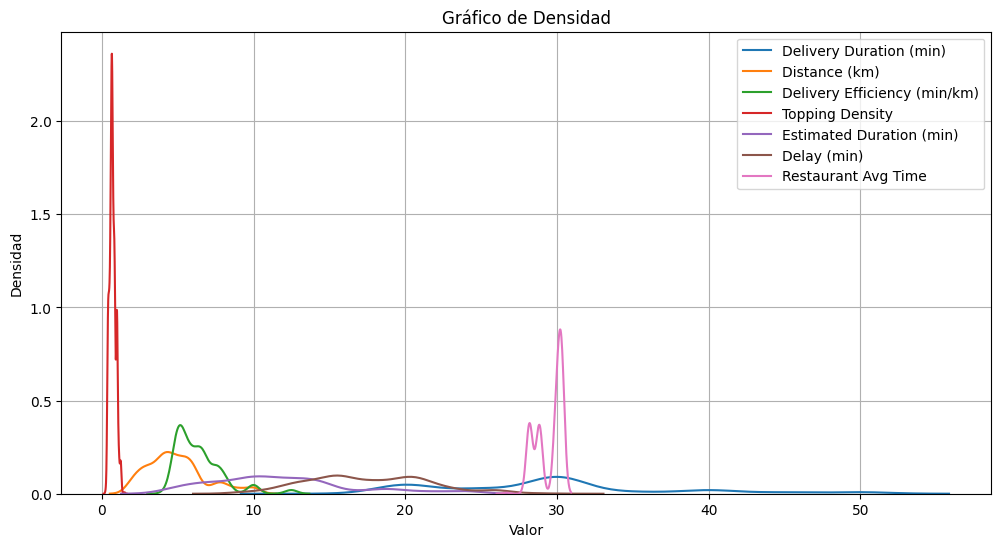

In [40]:
#Gracico de Densidad
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for col in columnas_a_redondear:
    sns.kdeplot(df[col], label=col, linewidth=1.5)

plt.title('Gráfico de Densidad')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()